# Exploratory Data Analysis (EDA)
Di sini kita akan mengeksplorasi dataset, baik gambar mentahnya maupun fitur-fitur HSI yang telah diekstraksi.

In [53]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Distribusi Kelas Kematangan Buah
Mari kita lihat seberapa seimbang data yang kita miliki di data *Train*.

C:\Users\haida\AppData\Local\Temp\ipykernel_25836\3774806182.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='label', order=['mentah', 'matang', 'terlalu matang'], palette='viridis')


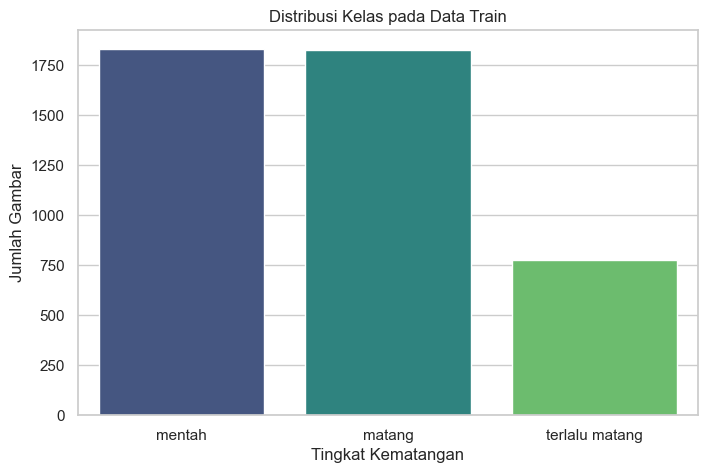

In [54]:
train_csv_path = os.path.join(src_path.replace('src', 'data'), 'processed', 'train_features.csv')
if os.path.exists(train_csv_path):
    df_train = pd.read_csv(train_csv_path)
    
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_train, x='label', order=['mentah', 'matang', 'terlalu matang'], palette='viridis')
    plt.title('Distribusi Kelas pada Data Train')
    plt.xlabel('Tingkat Kematangan')
    plt.ylabel('Jumlah Gambar')
    plt.show()
else:
    print("File train_features.csv belum dibuat. Harap jalankan 02_Preprocessing_and_Extraction.ipynb terlebih dahulu.")

## 2. Visualisasi Fitur HSI (Hue, Saturation, Intensity)
Kita akan menggunakan *Boxplot* untuk melihat apakah ada perbedaan nilai Hue (Corak) yang signifikan antara buah yang mentah, matang, dan terlalu matang.

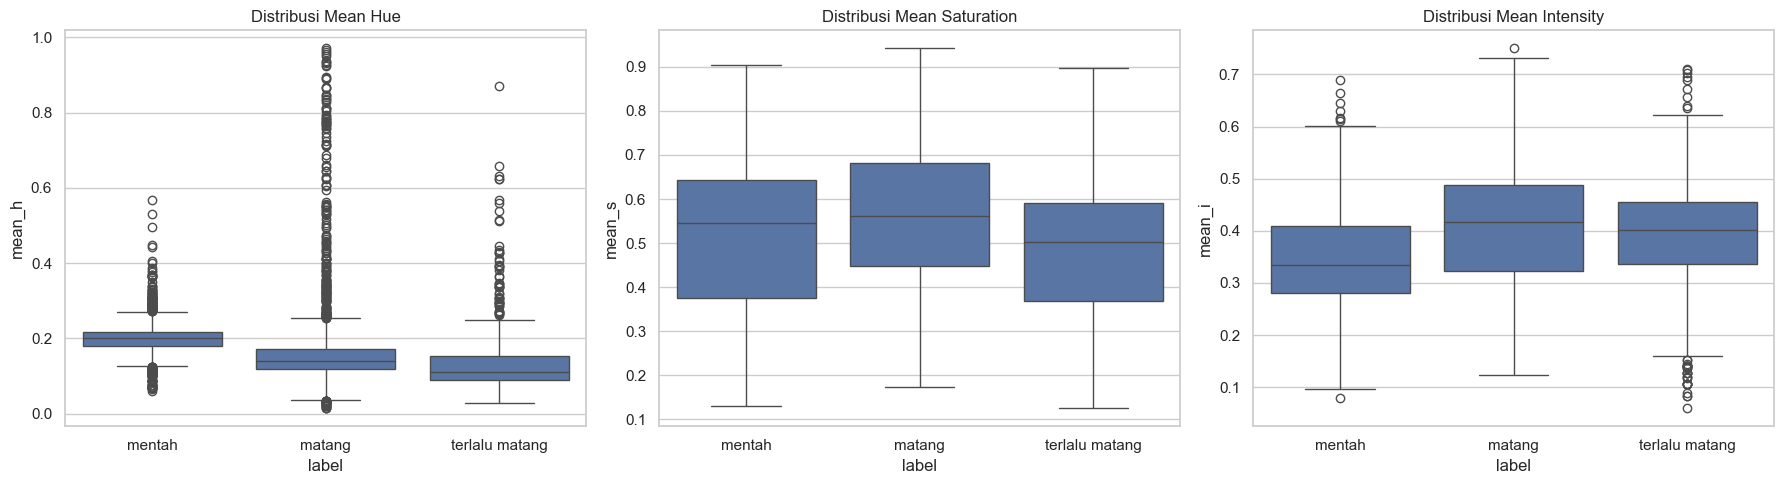

In [55]:
if os.path.exists(train_csv_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.boxplot(ax=axes[0], data=df_train, x='label', y='mean_h', order=['mentah', 'matang', 'terlalu matang'])
    axes[0].set_title('Distribusi Mean Hue')
    
    sns.boxplot(ax=axes[1], data=df_train, x='label', y='mean_s', order=['mentah', 'matang', 'terlalu matang'])
    axes[1].set_title('Distribusi Mean Saturation')
    
    sns.boxplot(ax=axes[2], data=df_train, x='label', y='mean_i', order=['mentah', 'matang', 'terlalu matang'])
    axes[2].set_title('Distribusi Mean Intensity')
    
    plt.tight_layout()
    plt.show()

## 3. Sampel Gambar Mentah vs Gambar Preprocessing
Mari kita lihat satu contoh gambar sebelum dan sesudah diberikan Gaussian Blur (dari `image_utils.py`).

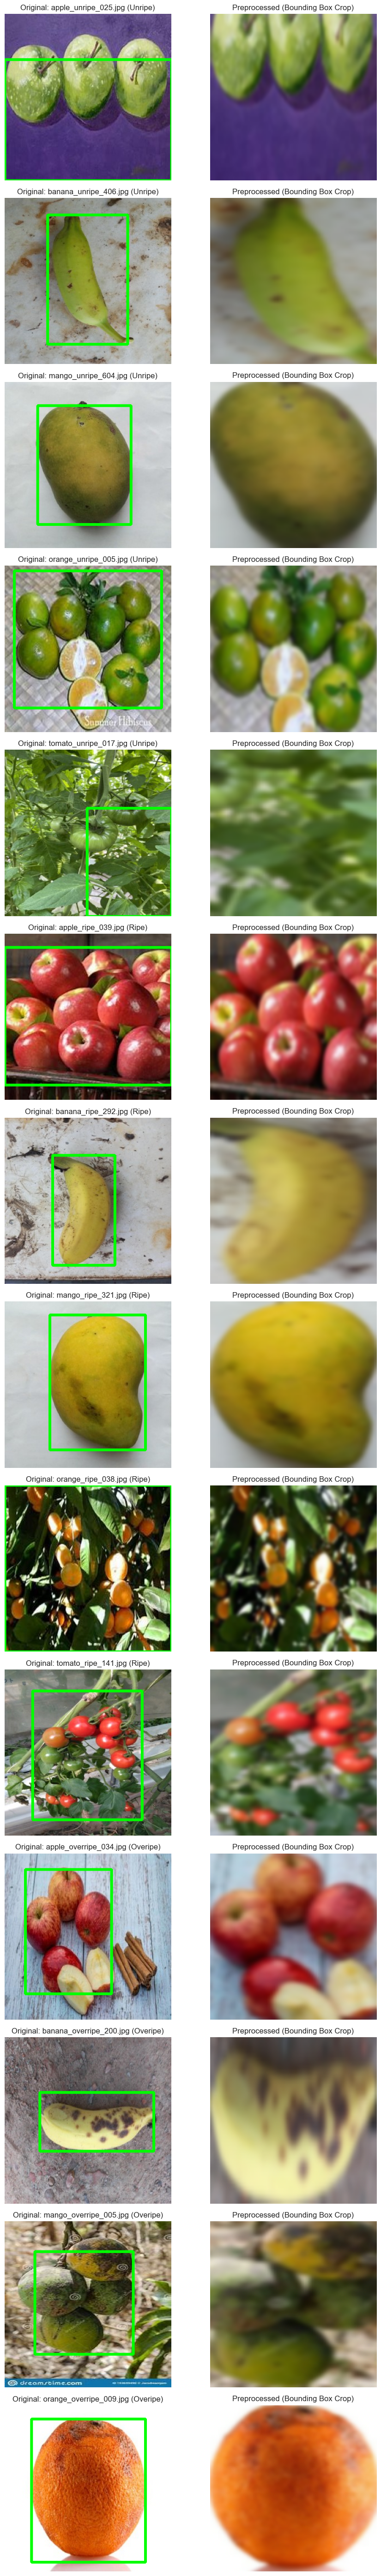

In [56]:
import os, glob
import matplotlib.pyplot as plt
import cv2
import image_utils
import importlib
importlib.reload(image_utils)
from image_utils import load_and_preprocess_image, get_fruit_bounding_box

states = ['Mentah (Unripe)', 'Matang (Ripe)', 'Terlalu Matang (Overipe)']
state_folders = ['Unripe', 'Ripe', 'Overipe']
fruits = ['apple', 'banana', 'mango', 'orange', 'tomato']
samples = []

for state_folder in state_folders:
    base_path = os.path.join('..', 'data', 'raw', 'Train', state_folder)
    if os.path.exists(base_path):
        files = glob.glob(os.path.join(base_path, '*.jpg'))
        for f in fruits:
            fruit_files = [x for x in files if os.path.basename(x).startswith(f)]
            if fruit_files:
                import random
                samples.append((state_folder, random.choice(fruit_files)))
                
if samples:
    fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))
    for i, (state, file_path) in enumerate(samples):
        img_raw = cv2.imread(file_path)
        img_raw_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
        
        bbox = get_fruit_bounding_box(file_path)
        if bbox:
            x, y, w, h = bbox
            cv2.rectangle(img_raw_rgb, (x, y), (x+w, y+h), (0, 255, 0), 3)
            
        img_prep = load_and_preprocess_image(file_path)
        img_prep_rgb = cv2.cvtColor(img_prep, cv2.COLOR_BGR2RGB)
        
        ax_raw = axes[i, 0] if len(samples) > 1 else axes[0]
        ax_prep = axes[i, 1] if len(samples) > 1 else axes[1]
        
        ax_raw.imshow(img_raw_rgb)
        ax_raw.set_title(f'Original: {os.path.basename(file_path)} ({state})')
        ax_raw.axis('off')
        
        ax_prep.imshow(img_prep_rgb)
        ax_prep.set_title('Preprocessed (Bounding Box Crop)')
        ax_prep.axis('off')
        
    plt.tight_layout()
    plt.show()
